In [91]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [92]:
df = pd.read_csv("datasets/car data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [93]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [94]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [95]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 301
Columns: 9


In [96]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [98]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [99]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [100]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)





Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [101]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
Car_Name,0,0.0
Year,0,0.0
Selling_Price,0,0.0
Present_Price,0,0.0
Driven_kms,0,0.0
Fuel_Type,0,0.0
Selling_type,0,0.0
Transmission,0,0.0
Owner,0,0.0


In [102]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 2


In [103]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(299, 9)


In [104]:
for column in df.columns:
    print("\n" + "=" * 50)
    print(column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].unique()[:20])


Car_Name
Number of unique values: 98
<ArrowStringArray>
[         'ritz',           'sx4',          'ciaz',       'wagon r',
         'swift', 'vitara brezza',       's cross',      'alto 800',
        'ertiga',         'dzire',      'alto k10',         'ignis',
           '800',        'baleno',          'omni',      'fortuner',
        'innova', 'corolla altis',   'etios cross',       'etios g']
Length: 20, dtype: str

Year
Number of unique values: 16
[2014 2013 2017 2011 2018 2015 2016 2009 2010 2012 2003 2008 2006 2005
 2004 2007]

Selling_Price
Number of unique values: 156
[3.35 4.75 7.25 2.85 4.6  9.25 6.75 6.5  8.75 7.45 6.85 7.5  6.1  2.25
 7.75 3.25 2.65 4.9  4.4  2.5 ]

Present_Price
Number of unique values: 148
[ 5.59  9.54  9.85  4.15  6.87  9.83  8.12  8.61  8.89  8.92  3.6  10.38
  9.94  7.71  7.21 10.79  5.09  7.98  3.95  5.71]

Driven_kms
Number of unique values: 206
[27000 43000  6900  5200 42450  2071 18796 33429 20273 42367  2135 51000
 15000 26000 77427 41678 35500

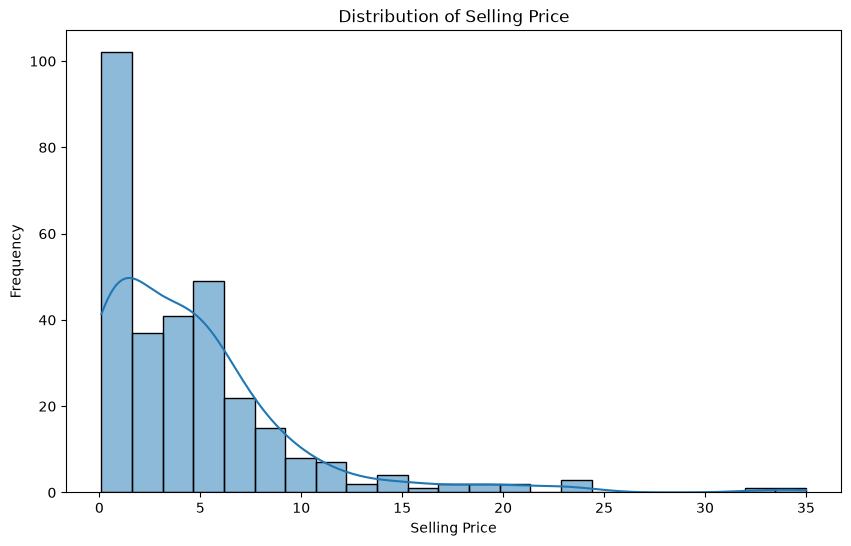

In [105]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Selling_Price",
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

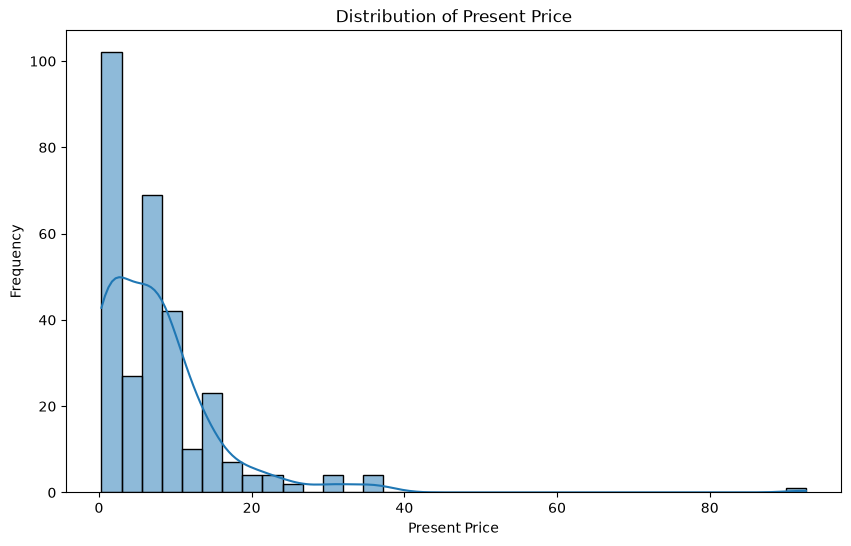

In [106]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Present_Price",
    kde=True
)

plt.title("Distribution of Present Price")
plt.xlabel("Present Price")
plt.ylabel("Frequency")

plt.show()

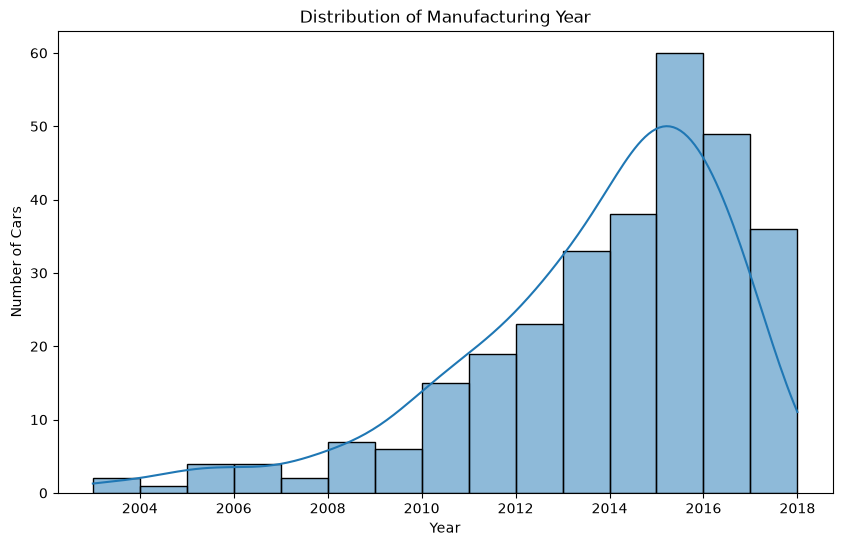

In [107]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Year",
    bins=15,
    kde=True
)

plt.title("Distribution of Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Number of Cars")

plt.show()

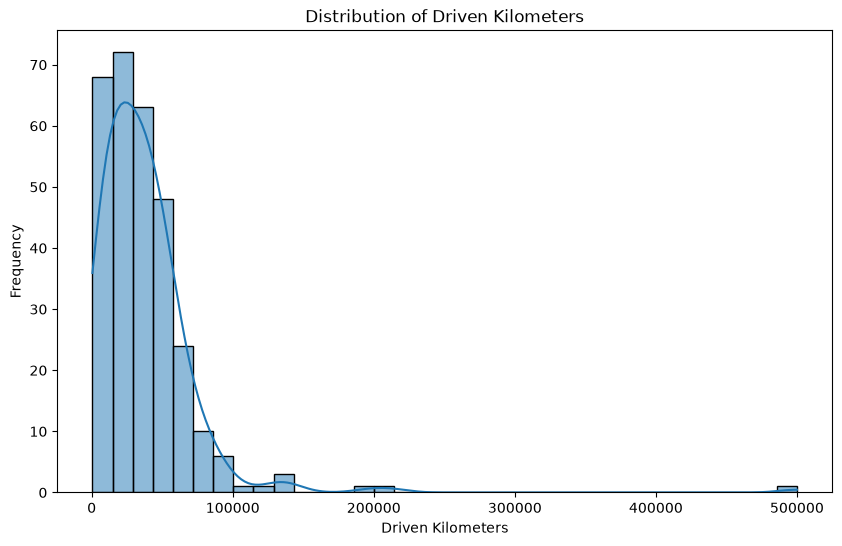

In [108]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Driven_kms",
    kde=True
)

plt.title("Distribution of Driven Kilometers")
plt.xlabel("Driven Kilometers")
plt.ylabel("Frequency")

plt.show()

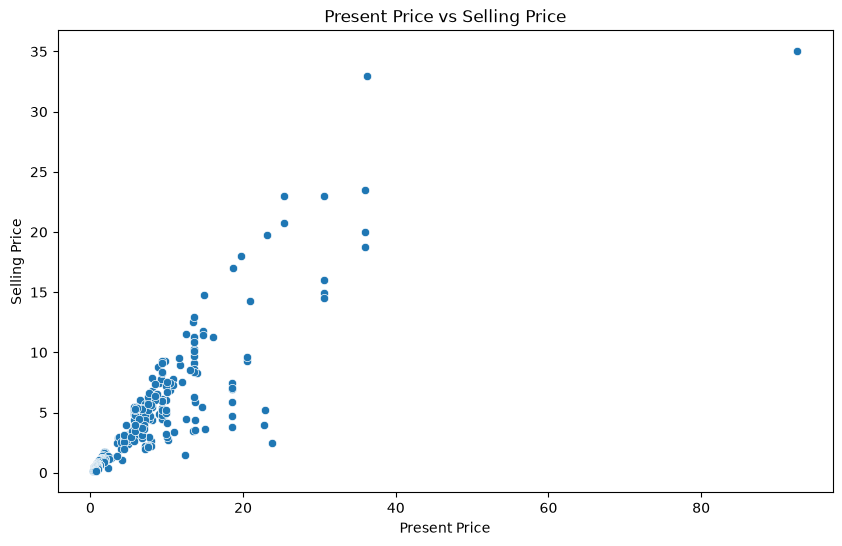

In [109]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

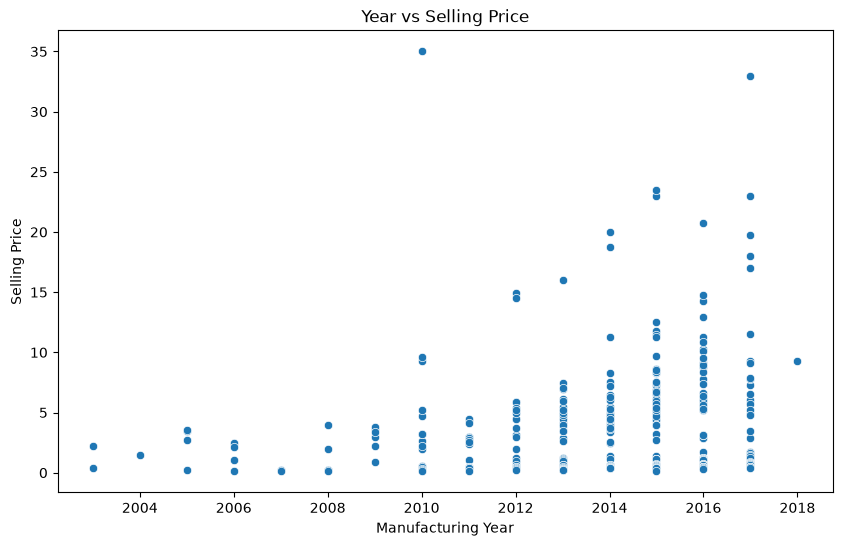

In [110]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price")

plt.show()

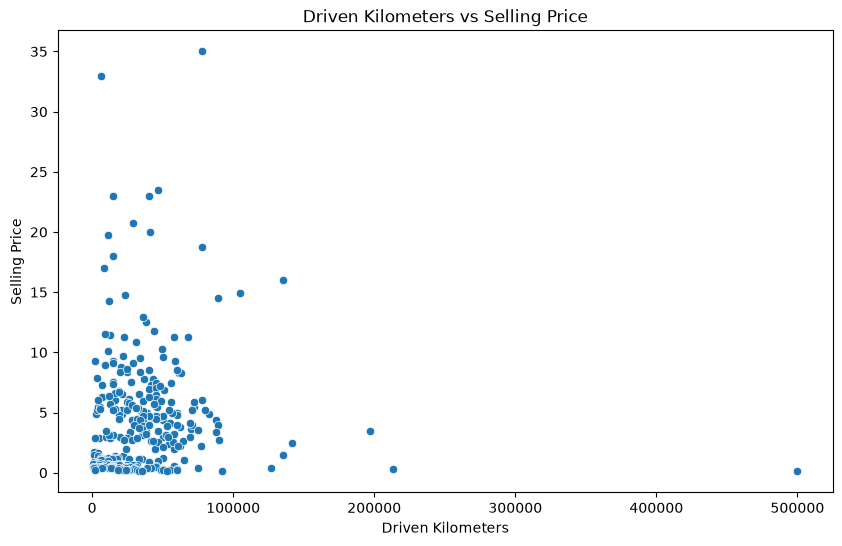

In [111]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price"
)

plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")

plt.show()

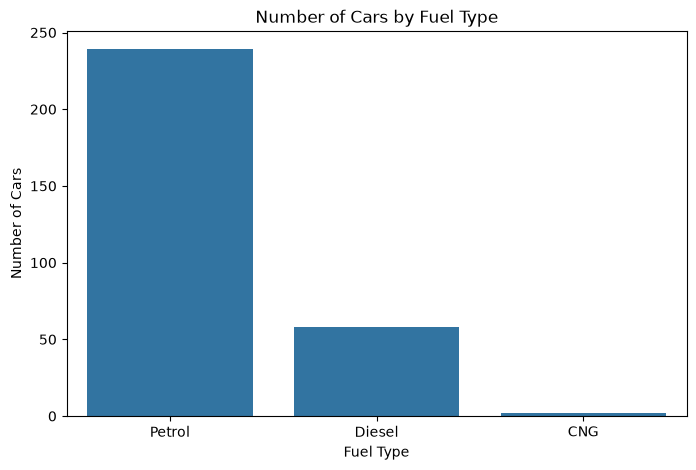

In [112]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Fuel_Type"
)

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

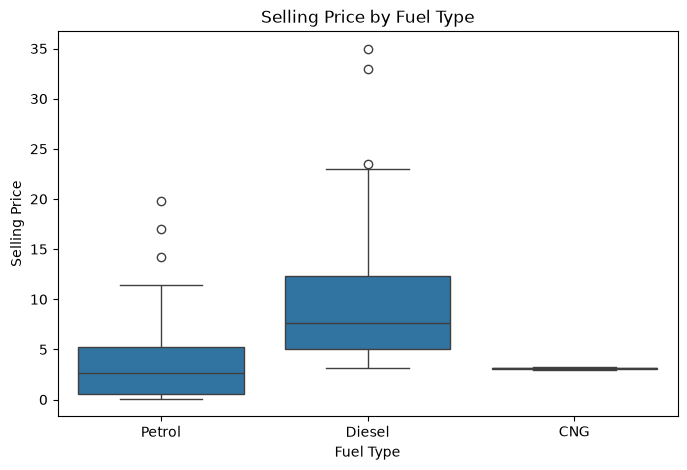

In [113]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

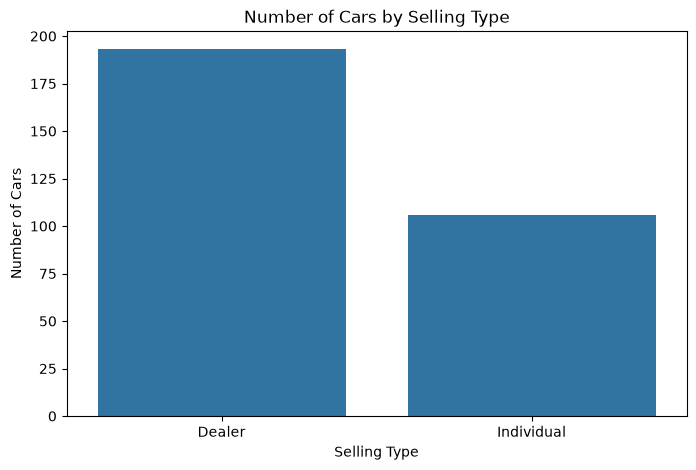

In [114]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Selling_type"
)

plt.title("Number of Cars by Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Number of Cars")

plt.show()

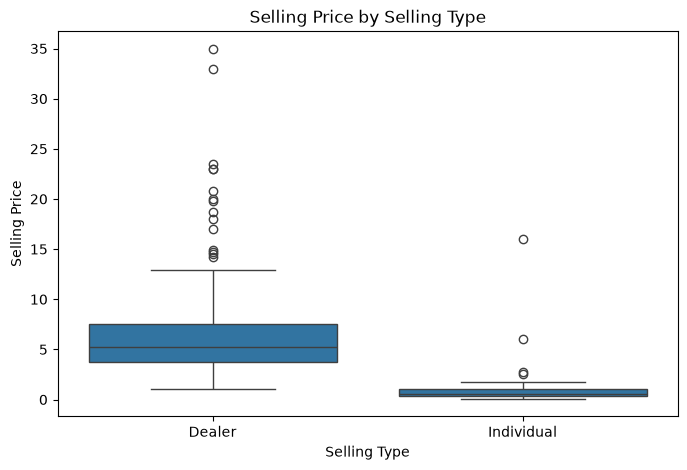

In [115]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Selling_type",
    y="Selling_Price"
)

plt.title("Selling Price by Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Selling Price")

plt.show()

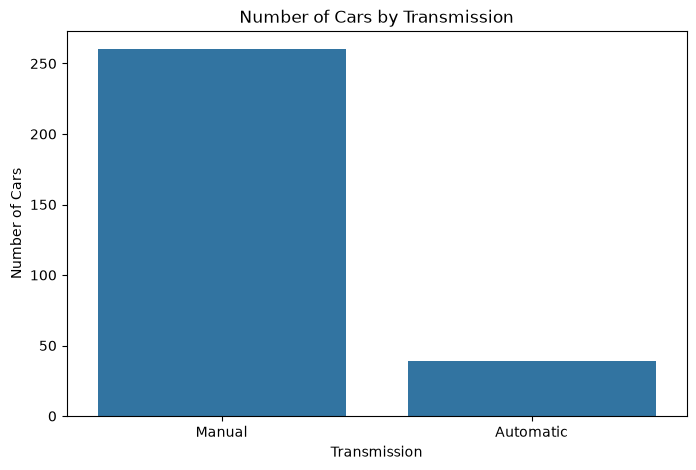

In [116]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Transmission"
)

plt.title("Number of Cars by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

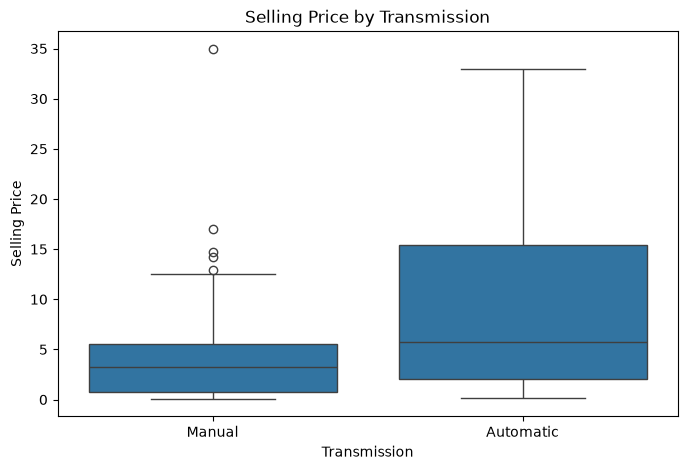

In [117]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)

plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

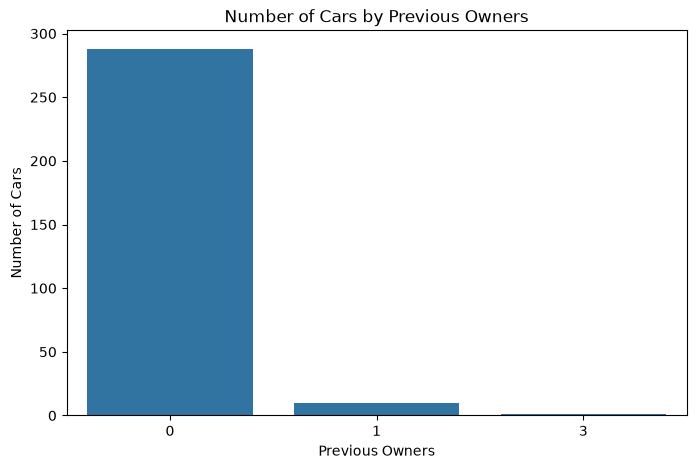

In [118]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Owner"
)

plt.title("Number of Cars by Previous Owners")
plt.xlabel("Previous Owners")
plt.ylabel("Number of Cars")

plt.show()

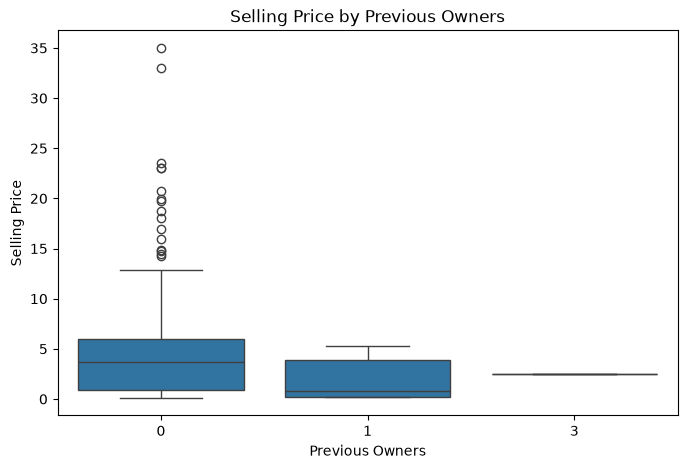

In [119]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Owner",
    y="Selling_Price"
)

plt.title("Selling Price by Previous Owners")
plt.xlabel("Previous Owners")
plt.ylabel("Selling Price")

plt.show()

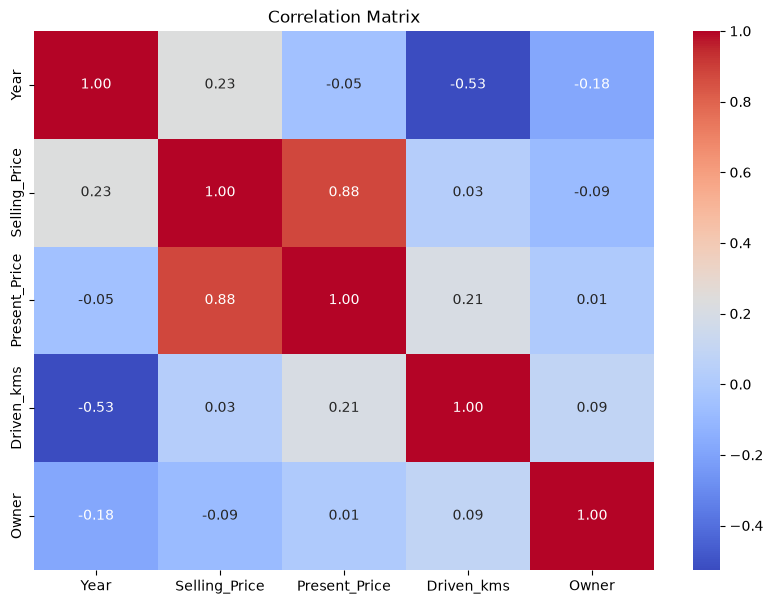

In [120]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [121]:
correlation_with_target = (
    numeric_df.corr()["Selling_Price"]
    .sort_values(ascending=False)
)

correlation_with_target

Selling_Price    1.000000
Present_Price    0.876305
Year             0.234369
Driven_kms       0.028566
Owner           -0.087880
Name: Selling_Price, dtype: float64

In [122]:
CURRENT_YEAR = 2026

df["Car_Age"] = CURRENT_YEAR - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [123]:
df[
    [
        "Year",
        "Car_Age",
        "Selling_Price"
    ]
].head(10)

,Year,Car_Age,Selling_Price
0,2014,12,3.35
1,2013,13,4.75
2,2017,9,7.25
3,2011,15,2.85
4,2014,12,4.60
5,2018,8,9.25
6,2015,11,6.75
7,2015,11,6.50
8,2016,10,8.75
9,2015,11,7.45


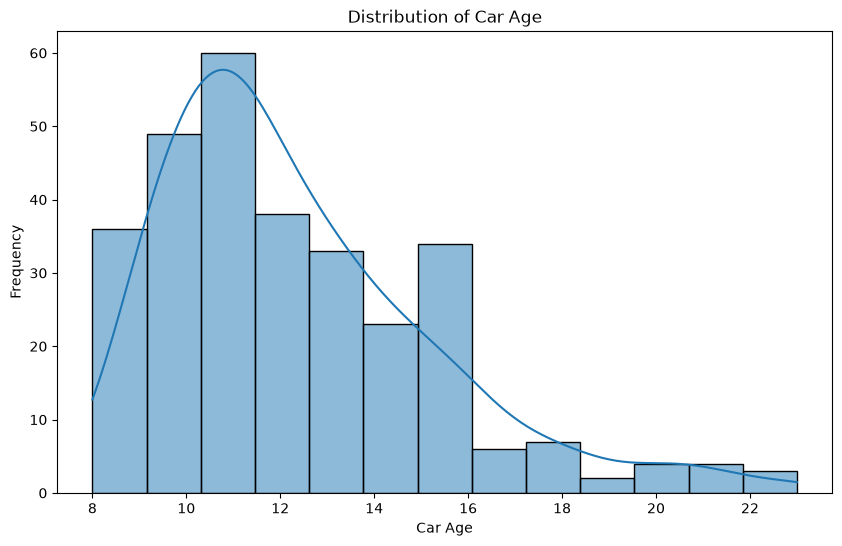

In [124]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Car_Age",
    kde=True
)

plt.title("Distribution of Car Age")
plt.xlabel("Car Age")
plt.ylabel("Frequency")

plt.show()

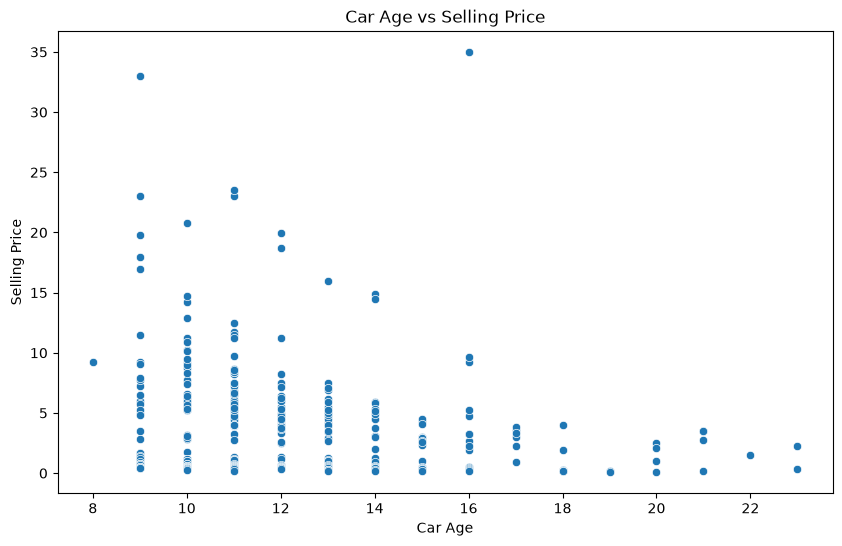

In [125]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

In [126]:
df_model = df.drop(
    columns=[
        "Car_Name",
        "Year"
    ]
)

df_model.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [127]:
print(df_model.columns.tolist())

['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [128]:
print("Shape:", df_model.shape)

df_model.info()

Shape: (299, 8)
<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  299 non-null    float64
 1   Present_Price  299 non-null    float64
 2   Driven_kms     299 non-null    int64  
 3   Fuel_Type      299 non-null    str    
 4   Selling_type   299 non-null    str    
 5   Transmission   299 non-null    str    
 6   Owner          299 non-null    int64  
 7   Car_Age        299 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 26.9 KB


In [129]:
X = df_model.drop(
    "Selling_Price",
    axis=1
)

y = df_model["Selling_Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 7)
y shape: (299,)


In [130]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']


In [131]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['Fuel_Type', 'Selling_type', 'Transmission']


In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 7)
Testing data: (60, 7)


In [133]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [134]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [135]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [137]:
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

In [138]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [139]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [140]:
gradient_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_model.fit(
    X_train,
    y_train
)

gradient_predictions = gradient_model.predict(
    X_test
)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [141]:
extra_trees_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

extra_trees_model.fit(
    X_train,
    y_train
)

extra_predictions = extra_trees_model.predict(
    X_test
)

print("Extra Trees trained successfully!")

Extra Trees trained successfully!


In [142]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [143]:
def evaluate_model(
    model_name,
    actual,
    predicted
):
    
    mae = mean_absolute_error(
        actual,
        predicted
    )
    
    mse = mean_squared_error(
        actual,
        predicted
    )
    
    rmse = np.sqrt(mse)
    
    r2 = r2_score(
        actual,
        predicted
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [144]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_predictions
    )
)

results.append(
    evaluate_model(
        "Extra Trees",
        y_test,
        extra_predictions
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.472546,6.373125,2.524505,0.752723
1,Random Forest,1.525259,13.477981,3.671237,0.477056
2,Gradient Boosting,1.135959,6.143967,2.478703,0.761615
3,Extra Trees,1.042339,5.190532,2.278274,0.798608


In [145]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Extra Trees,1.042339,5.190532,2.278274,0.798608
1,Gradient Boosting,1.135959,6.143967,2.478703,0.761615
2,Linear Regression,1.472546,6.373125,2.524505,0.752723
3,Random Forest,1.525259,13.477981,3.671237,0.477056


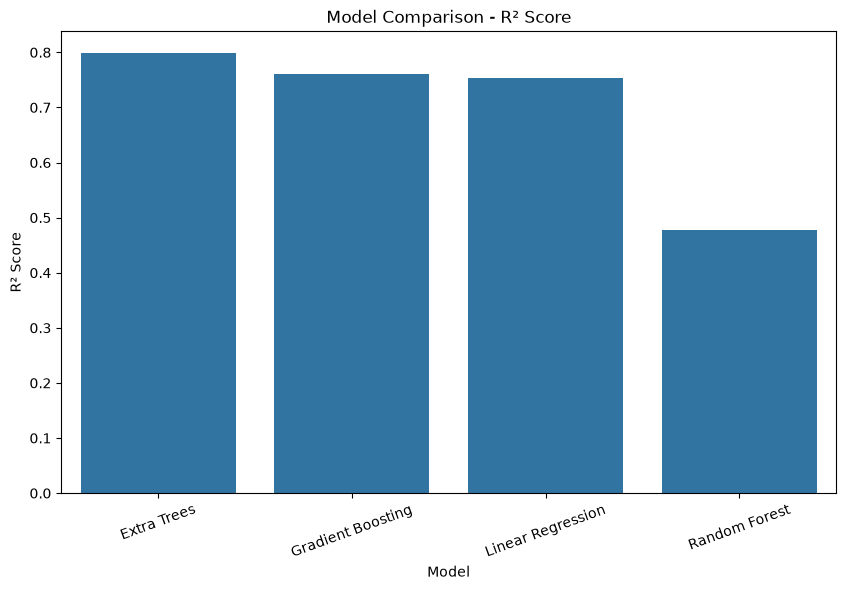

In [146]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

In [147]:
best_model_name = results_df.loc[
    0,
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Extra Trees


In [148]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_model,
    "Extra Trees": extra_trees_model
}

best_model = models[
    best_model_name
]

print(
    "Selected Model:",
    best_model_name
)

Selected Model: Extra Trees


In [149]:
best_predictions = best_model.predict(
    X_test
)

print("Predictions generated successfully!")

Predictions generated successfully!


In [150]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

comparison_df.head(15)

,Actual Price,Predicted Price
0,8.99,9.276833
1,8.35,8.645700
2,0.45,0.468500
3,7.45,7.129500
4,5.25,13.533333
5,5.25,5.182667
6,5.85,6.241567
7,1.15,1.207167
8,9.25,8.218333
9,0.38,0.432567


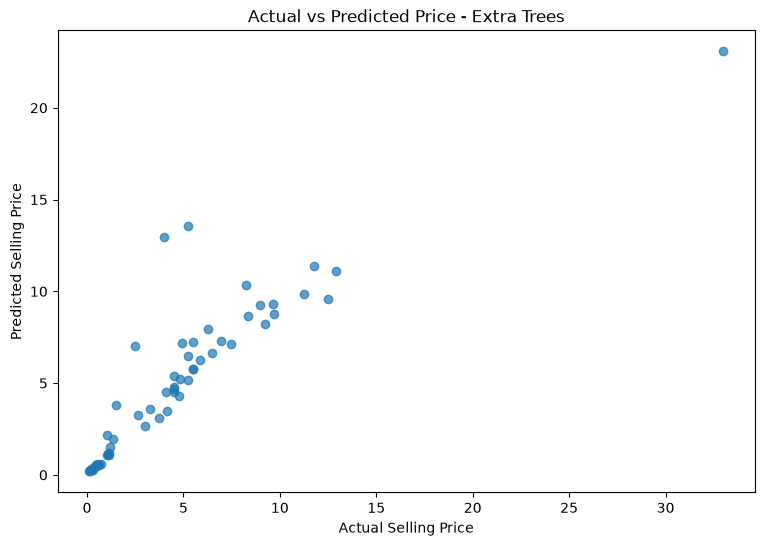

In [151]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title(
    f"Actual vs Predicted Price - {best_model_name}"
)

plt.show()

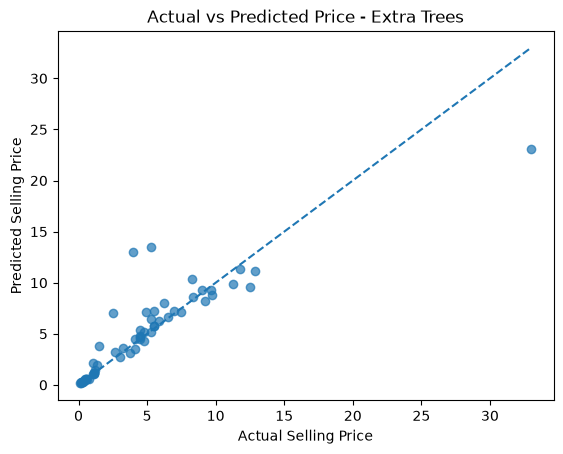

In [152]:
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title(
    f"Actual vs Predicted Price - {best_model_name}"
)

plt.show()

In [153]:
residuals = (
    y_test.values -
    best_predictions
)

print(residuals[:10])

[-0.28683333 -0.2957     -0.0185      0.3205     -8.28333333  0.06733333
 -0.39156667 -0.05716667  1.03166667 -0.05256667]


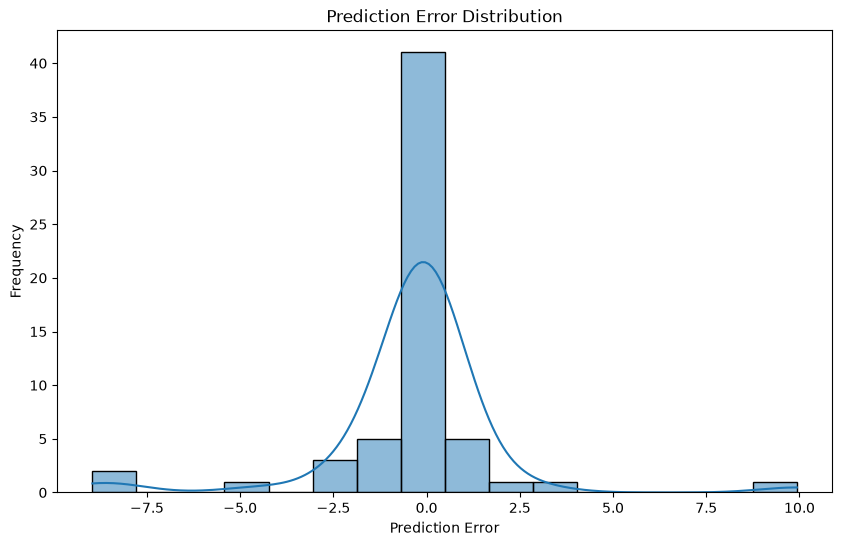

In [154]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

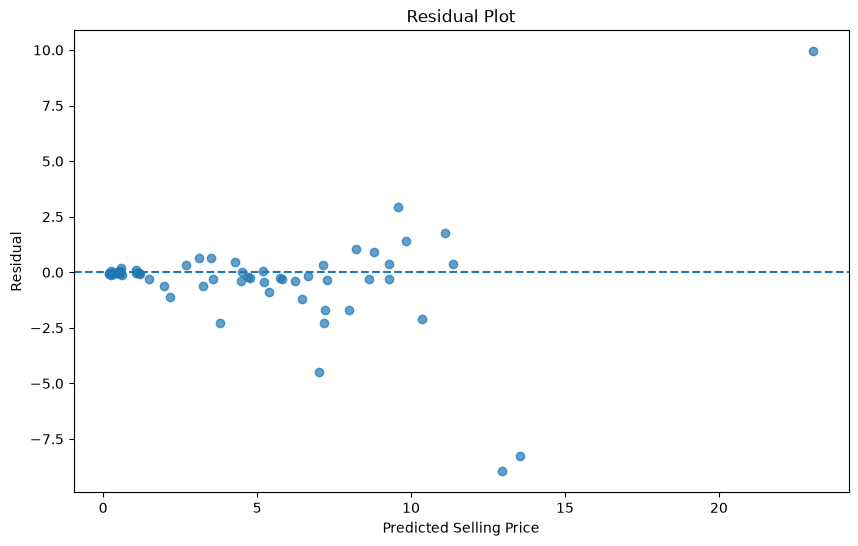

In [155]:
plt.figure(figsize=(10, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [156]:
final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_mse = mean_squared_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    final_mse
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Best Model:", best_model_name)
print("MAE:", round(final_mae, 4))
print("MSE:", round(final_mse, 4))
print("RMSE:", round(final_rmse, 4))
print("R² Score:", round(final_r2, 4))

FINAL MODEL PERFORMANCE
Best Model: Extra Trees
MAE: 1.0423
MSE: 5.1905
RMSE: 2.2783
R² Score: 0.7986


In [157]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("5-Fold CV Scores:")
print(cv_scores)

print(
    "\nMean CV R²:",
    round(cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(cv_scores.std(), 4)
)

5-Fold CV Scores:
[0.8199605  0.77494069 0.42187037 0.9412049  0.87544651]

Mean CV R²: 0.7667
CV Standard Deviation: 0.1812


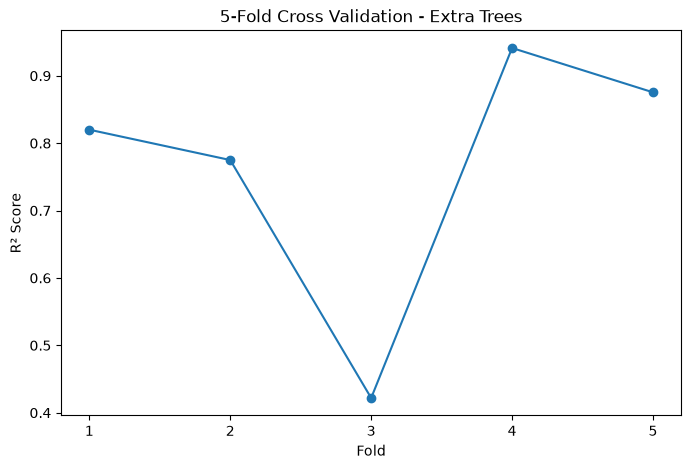

In [158]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o"
)

plt.xlabel("Fold")
plt.ylabel("R² Score")

plt.title(
    f"5-Fold Cross Validation - {best_model_name}"
)

plt.xticks(range(1, 6))

plt.show()

In [159]:
if best_model_name in [
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]:
    
    trained_preprocessor = (
        best_model.named_steps["preprocessor"]
    )
    
    trained_model = (
        best_model.named_steps["model"]
    )
    
    feature_names = (
        trained_preprocessor
        .get_feature_names_out()
    )
    
    importances = (
        trained_model.feature_importances_
    )
    
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(
        by="Importance",
        ascending=False
    )
    
    display(
        feature_importance_df.head(20)
    )

else:
    print(
        "Feature importance is not directly available."
    )

,Feature,Importance
0,numerical__Present_Price,0.473578
7,categorical__Selling_type_Dealer,0.231858
3,numerical__Car_Age,0.070822
10,categorical__Transmission_Manual,0.059769
5,categorical__Fuel_Type_Diesel,0.051035
9,categorical__Transmission_Automatic,0.040556
6,categorical__Fuel_Type_Petrol,0.037118
1,numerical__Driven_kms,0.024759
8,categorical__Selling_type_Individual,0.010364
2,numerical__Owner,0.000086


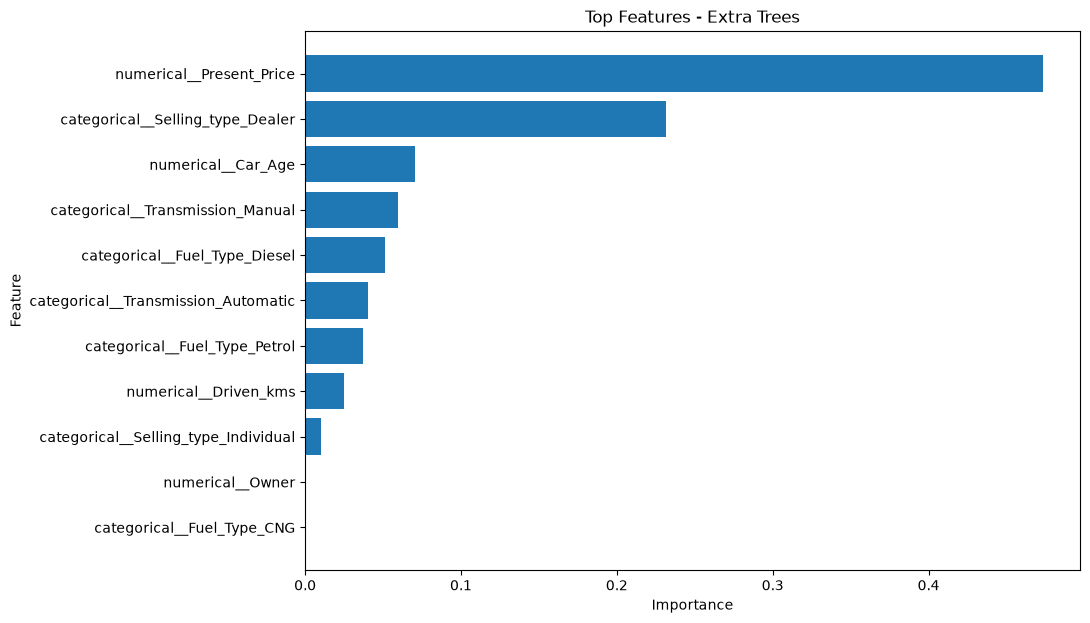

In [160]:
if best_model_name in [
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]:
    
    top_features = (
        feature_importance_df
        .head(15)
        .sort_values(
            by="Importance"
        )
    )
    
    plt.figure(figsize=(10, 7))
    
    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )
    
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    
    plt.title(
        f"Top Features - {best_model_name}"
    )
    
    plt.show()

In [161]:
sample_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Driven_kms": [30000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0],
    "Car_Age": [3]
})

sample_car

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,8.5,30000,Petrol,Dealer,Manual,0,3


In [162]:
sample_prediction = best_model.predict(
    sample_car
)

print(
    "Predicted Selling Price:",
    round(
        sample_prediction[0],
        2
    ),
    "Lakhs"
)

Predicted Selling Price: 6.53 Lakhs


In [171]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

print("Models directory ready!")

Models directory ready!


In [175]:
import joblib

model_path = (
    "models/car_price_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: models/car_price_model.pkl


In [176]:
model_info = {
    "model_name": best_model_name,
    "features": X.columns.tolist(),
    "target": "Selling_Price",
    "current_year": CURRENT_YEAR,
    "mae": final_mae,
    "rmse": final_rmse,
    "r2_score": final_r2
}

joblib.dump(
    model_info,
    "models/model_info.pkl"
)

print("Model information saved successfully!")

Model information saved successfully!


In [177]:
loaded_model = joblib.load(
    "models/car_price_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [178]:
loaded_prediction = loaded_model.predict(
    sample_car
)

print(
    "Prediction from saved model:",
    round(
        loaded_prediction[0],
        2
    ),
    "Lakhs"
)

Prediction from saved model: 6.53 Lakhs


In [179]:
print(
    "Original prediction:",
    round(
        sample_prediction[0],
        4
    )
)

print(
    "Loaded model prediction:",
    round(
        loaded_prediction[0],
        4
    )
)

Original prediction: 6.5307
Loaded model prediction: 6.5307


In [180]:
print("=" * 60)
print("🚗 CAR PRICE PREDICTION - FINAL SUMMARY")
print("=" * 60)

print(
    f"Original Dataset Shape: {df.shape}"
)

print(
    f"Model Dataset Shape: {df_model.shape}"
)

print(
    f"Training Samples: {len(X_train)}"
)

print(
    f"Testing Samples: {len(X_test)}"
)

print(
    f"\nBest Model: {best_model_name}"
)

print(
    f"MAE: {final_mae:.4f}"
)

print(
    f"RMSE: {final_rmse:.4f}"
)

print(
    f"R² Score: {final_r2:.4f}"
)

print(
    f"Mean CV R²: {cv_scores.mean():.4f}"
)

print(
    "\nModel saved at:"
)

print(
    "models/car_price_model.pkl"
)

print("=" * 60)

🚗 CAR PRICE PREDICTION - FINAL SUMMARY
Original Dataset Shape: (299, 10)
Model Dataset Shape: (299, 8)
Training Samples: 239
Testing Samples: 60

Best Model: Extra Trees
MAE: 1.0423
RMSE: 2.2783
R² Score: 0.7986
Mean CV R²: 0.7667

Model saved at:
models/car_price_model.pkl
